# 02 — Grid Construction & Tree Aggregation

**Purpose:** Build a 400 m × 400 m decision-unit grid over the Barcelona
municipal boundary, join all ~189 k trees into grid cells, and compute
per-cell mycorrhizal type fractions.

**Decision unit rationale:** The Superilla block is ~400 m across.
A 400 m grid satisfies the 2× Nyquist rule (tree points are native-resolution
individual locations), aligns with the project brief, and keeps cell count
tractable (~1 500 cells covering urban BCN).

**CRS:** ETRS89 / UTM Zone 31N (EPSG:25831) throughout — metre-unit CRS
native to the source data's `x_etrs89` / `y_etrs89` columns.

**Inputs:**
- `data/arbrat-viari.csv` — 145 478 street trees
- `data/arbrat-zona.csv` — 43 612 park trees
- `data/bcn-boundary.geojson` — Barcelona municipal polygon
- `data/fungalroot.csv` — optional; if absent a hardcoded stub is used

**Output:** `data/grid_trees.geojson` — one row per occupied grid cell
with tree counts, species lists, district, and mycorrhizal fractions.

**Pipeline steps:**
1. P1 — Build 400 m grid clipped to BCN boundary
2. P2 — Load & reproject tree inventory to EPSG:25831
3. P3 — Spatial join trees → grid cells
4. P4 — Per-cell aggregation (count, species list, district, barri)
5. P5 — FungalRoot type join (file or hardcoded stub)
6. P6 — Compute dominant mycorrhizal type + AM/EM/NM fractions
7. P7 — AM-blindness flag + colonisation-uncertainty metric
8. Save + summary statistics

## Cell 1 — Imports and configuration

We pin the GRID_SIZE constant here so changing the decision-unit resolution
only requires editing this one value.

`tqdm.pandas()` patches `DataFrame.progress_apply` — useful for row-wise
operations over the ~189 k-row tree table.

In [46]:
import json
import sys
import warnings
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import box
from tqdm.auto import tqdm

tqdm.pandas(desc="progress")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)

# ── Constants ──────────────────────────────────────────────────────────────
GRID_SIZE   = 400          # metres — matches Superilla block width
CRS_PROJ    = "EPSG:25831" # ETRS89 / UTM Zone 31N
CRS_GEO     = "EPSG:4326"  # WGS-84 (input lon/lat)

# Approximate UTM31N bounding box for BCN (used as fallback if boundary
# file is unavailable — NOT used when the boundary file is present).
BCN_XMIN, BCN_XMAX = 422_000, 435_000
BCN_YMIN, BCN_YMAX = 4_577_000, 4_592_000

# Paths (relative to repo root — notebook should be run from repo root or
# notebooks/ folder; we resolve the data dir relative to this file).
NOTEBOOK_DIR = Path(".").resolve()
# If we're inside notebooks/ shift one level up
DATA_DIR = (NOTEBOOK_DIR / "data") if (NOTEBOOK_DIR / "data").exists() \
           else (NOTEBOOK_DIR.parent / "data")
OUT_FILE = DATA_DIR / "grid_trees.geojson"

print(f"Data directory : {DATA_DIR}")
print(f"Output file    : {OUT_FILE}")
print(f"Grid cell size : {GRID_SIZE} m")
print(f"CRS            : {CRS_PROJ}")

Data directory : C:\Users\Rafik\Documents\GitHub\group4-data-for-all\data
Output file    : C:\Users\Rafik\Documents\GitHub\group4-data-for-all\data\grid_trees.geojson
Grid cell size : 400 m
CRS            : EPSG:25831


## Cell 2 — Guard: verify input files exist

Before touching any geometry code we verify the required CSVs are present.
If they are missing we print clear download instructions and stop the kernel
cleanly rather than letting cryptic errors propagate later.

In [47]:
REQUIRED_FILES = {
    "Street trees"  : DATA_DIR / "arbrat-viari.csv",
    "Park trees"    : DATA_DIR / "arbrat-zona.csv",
    "BCN boundary"  : DATA_DIR / "bcn-boundary.geojson",
}

DOWNLOAD_INSTRUCTIONS = """
─────────────────────────────────────────────────────────────────────────────
 MISSING INPUT FILES — run the download script first:

     python download_data.py

 Manual download URLs:
   arbrat-viari.csv  → https://opendata-ajuntament.barcelona.cat/data/ca/dataset/arbrat-viari
   arbrat-zona.csv   → https://opendata-ajuntament.barcelona.cat/data/ca/dataset/arbrat-zona
   bcn-boundary.geojson → already bundled; run: git lfs pull
─────────────────────────────────────────────────────────────────────────────
"""

missing = [name for name, path in REQUIRED_FILES.items() if not path.exists()]

if missing:
    print(f"ERROR: {len(missing)} required file(s) not found:")
    for m in missing:
        print(f"  ✗  {m:15s}  ({REQUIRED_FILES[m]})")
    print(DOWNLOAD_INSTRUCTIONS)
    # Raise SystemExit so the rest of the notebook is skipped cleanly
    # when run as a script; in interactive mode you can comment this out.
    raise SystemExit("Stopping: download inputs and re-run from Cell 1.")

print("All required input files found:")
for name, path in REQUIRED_FILES.items():
    size_mb = path.stat().st_size / 1_048_576
    print(f"  ✓  {name:15s}  ({size_mb:.1f} MB)")

All required input files found:
  ✓  Street trees     (41.2 MB)
  ✓  Park trees       (13.4 MB)
  ✓  BCN boundary     (0.2 MB)


## P1 — Build 400 m grid clipped to the BCN municipal boundary

**Algorithm:**
1. Load the boundary polygon from `bcn-boundary.geojson` and reproject to
   EPSG:25831 so all distances are in metres.
2. Derive a bounding box from the boundary envelope, snapped to the nearest
   400 m multiple so the grid is globally aligned (reproducible across runs).
3. Generate every 400 m × 400 m `shapely.box` tile that intersects the
   envelope.
4. Clip to the municipal polygon — cells that are entirely outside BCN are
   dropped; partial cells on the edge are retained (they will be filtered
   later to ≥1 tree).

We keep only cells with ≥1 tree (P3/P4) rather than dropping ocean/mountain
cells here, so the boundary clip is intentionally generous.

In [48]:
# ── Load boundary ──────────────────────────────────────────────────────────
boundary_raw = gpd.read_file(DATA_DIR / "bcn-boundary.geojson")
boundary = boundary_raw.to_crs(CRS_PROJ)
bcn_poly = boundary.union_all()          # single polygon / multipolygon

minx, miny, maxx, maxy = bcn_poly.bounds
print(f"Boundary bounds (UTM31N):")
print(f"  X: {minx:,.0f}  –  {maxx:,.0f}  ({maxx - minx:,.0f} m wide)")
print(f"  Y: {miny:,.0f}  –  {maxy:,.0f}  ({maxy - miny:,.0f} m tall)")

# ── Snap bounding box to GRID_SIZE multiples for reproducibility ───────────
import math
x0 = math.floor(minx / GRID_SIZE) * GRID_SIZE
y0 = math.floor(miny / GRID_SIZE) * GRID_SIZE
x1 = math.ceil(maxx  / GRID_SIZE) * GRID_SIZE
y1 = math.ceil(maxy  / GRID_SIZE) * GRID_SIZE

cols_n = int((x1 - x0) / GRID_SIZE)
rows_n = int((y1 - y0) / GRID_SIZE)
total_tiles = cols_n * rows_n
print(f"\nGrid envelope (snapped): X [{x0:,} – {x1:,}]  Y [{y0:,} – {y1:,}]")
print(f"Grid dimensions         : {cols_n} cols × {rows_n} rows = {total_tiles:,} raw tiles")

# ── Build tile geometries ──────────────────────────────────────────────────
tiles = []
xs = np.arange(x0, x1, GRID_SIZE)
ys = np.arange(y0, y1, GRID_SIZE)

for xi in tqdm(xs, desc="Building grid rows"):
    for yi in ys:
        tile = box(xi, yi, xi + GRID_SIZE, yi + GRID_SIZE)
        if tile.intersects(bcn_poly):
            tiles.append({
                "geometry": tile,
                "cell_id": f"C{int((xi - x0)/GRID_SIZE):03d}_{int((yi - y0)/GRID_SIZE):03d}",
                "cell_x0": int(xi),
                "cell_y0": int(yi),
            })

grid = gpd.GeoDataFrame(tiles, crs=CRS_PROJ)
print(f"\nTiles intersecting BCN boundary: {len(grid):,}")

Boundary bounds (UTM31N):
  X: 420,826  –  435,506  (14,679 m wide)
  Y: 4,574,282  –  4,591,027  (16,744 m tall)

Grid envelope (snapped): X [420,800 – 435,600]  Y [4,574,000 – 4,591,200]
Grid dimensions         : 37 cols × 43 rows = 1,591 raw tiles


Building grid rows:   0%|          | 0/37 [00:00<?, ?it/s]


Tiles intersecting BCN boundary: 772


## P2 — Load & reproject the tree inventory

The CSV files already carry `x_etrs89` / `y_etrs89` in EPSG:25831 —
these are the authoritative coordinate columns from the Ajuntament.
We use them directly and construct a `GeoDataFrame` from them, avoiding
any WGS-84 reprojection error.

We also parse `data_plantacio` here so the colonisation-uncertainty
metric (trees planted within the last 5 years) can be computed in P7.

In [49]:
def load_trees(path: Path, source_tag: str) -> pd.DataFrame:
    """Load one tree CSV and tag source."""
    df = pd.read_csv(path, encoding="utf-8", low_memory=False)
    df["source"] = source_tag
    return df

viari = load_trees(DATA_DIR / "arbrat-viari.csv", "street")
zona  = load_trees(DATA_DIR / "arbrat-zona.csv",  "park")
trees_raw = pd.concat([viari, zona], ignore_index=True)

print(f"Street trees : {len(viari):>7,}")
print(f"Park trees   : {len(zona):>7,}")
print(f"Combined     : {len(trees_raw):>7,}")

# ── Drop rows without valid coordinates ───────────────────────────────────
coord_mask = trees_raw["x_etrs89"].notna() & trees_raw["y_etrs89"].notna()
trees_clean = trees_raw[coord_mask].copy()
dropped = len(trees_raw) - len(trees_clean)
if dropped:
    print(f"Dropped {dropped} rows with null coordinates")

# ── Parse planting date ────────────────────────────────────────────────────
if "data_plantacio" in trees_clean.columns:
    trees_clean["plant_date"] = pd.to_datetime(
        trees_clean["data_plantacio"], errors="coerce"
    )
else:
    trees_clean["plant_date"] = pd.NaT

# ── Build GeoDataFrame directly from UTM31N coordinates ───────────────────
from shapely.geometry import Point

print("Building point geometries from x_etrs89 / y_etrs89 …")
geom = gpd.points_from_xy(
    trees_clean["x_etrs89"],
    trees_clean["y_etrs89"],
)
trees = gpd.GeoDataFrame(trees_clean, geometry=geom, crs=CRS_PROJ)

print(f"\nGeometry type : {trees.geom_type.unique()}")
print(f"CRS           : {trees.crs}")
print(f"Rows          : {len(trees):,}")

# Keep only the columns we need to stay memory-efficient
KEEP_COLS = [
    "codi", "cat_nom_cientific", "nom_districte", "nom_barri",
    "codi_districte", "codi_barri", "source", "plant_date", "geometry"
]
trees = trees[[c for c in KEEP_COLS if c in trees.columns]]
print(f"Retained columns: {list(trees.columns)}")

Street trees : 145,486
Park trees   :  43,734
Combined     : 189,220
Building point geometries from x_etrs89 / y_etrs89 …

Geometry type : <StringArray>
['Point']
Length: 1, dtype: str
CRS           : EPSG:25831
Rows          : 189,220
Retained columns: ['codi', 'cat_nom_cientific', 'nom_districte', 'nom_barri', 'codi_districte', 'codi_barri', 'source', 'plant_date', 'geometry']


## P3 — Spatial join: trees → grid cells

We use a `sjoin` with `predicate='within'`.  Because both layers share
EPSG:25831 no reprojection happens here.

Trees that fall exactly on a cell boundary are assigned to one cell by the
`within` predicate (boundary points are *not* within any cell — they fall
into the adjacent cell via `intersects` if needed).  The number of
boundary-edge trees is negligible (<0.1%) so we accept this.

The join adds `cell_id` to each tree row, making the aggregation in P4
a straightforward `groupby`.

In [50]:
print("Running spatial join (trees within grid cells) …")
print(f"  Trees : {len(trees):,} points")
print(f"  Grid  : {len(grid):,} cells")

# sjoin: predicate='within' — tree point falls strictly inside the cell box.
# We use 'intersects' as fallback for boundary-edge trees: if a tree is not
# 'within' any cell it won't appear in this join, so the count may be
# slightly lower than total trees — acceptable.
joined = gpd.sjoin(
    trees,
    grid[["cell_id", "geometry"]],
    how="inner",
    predicate="within",
)

matched = len(joined)
total   = len(trees)
unmatched = total - matched

print(f"\nTrees matched to a cell : {matched:,}  ({matched/total*100:.2f}%)")
print(f"Trees not within any cell: {unmatched:,}  ({unmatched/total*100:.2f}%)")
print(f"Cells with ≥1 tree       : {joined['cell_id'].nunique():,}")

# Drop the sjoin-added index column
joined = joined.drop(columns=["index_right"], errors="ignore")

Running spatial join (trees within grid cells) …
  Trees : 189,220 points
  Grid  : 772 cells

Trees matched to a cell : 189,140  (99.96%)
Trees not within any cell: 80  (0.04%)
Cells with ≥1 tree       : 495


## P4 — Per-cell aggregation

For each grid cell we compute:
- `tree_count` — total trees
- `species_list` — deduplicated list of scientific names (JSON-serialisable)
- `district_name` — modal district (most frequent among trees in the cell)
- `barri_name` — modal neighbourhood
- `trees_young_pct` — % of trees with `plant_date` ≤ 5 years ago
  (proxy for "colonisation uncertain" — mycorrhizal establishment takes
  2–5 years and these trees may not yet host the expected fungal community)

The `species_list` is stored as a JSON string so it survives round-tripping
through GeoJSON format.

In [51]:
TODAY = pd.Timestamp.now()
YOUNG_THRESHOLD = TODAY - pd.DateOffset(years=5)

def modal(series: pd.Series, default="UNKNOWN") -> str:
    """Return the most frequent non-null value in a series."""
    counts = series.dropna().value_counts()
    return str(counts.index[0]) if len(counts) else default

def species_list_json(series: pd.Series) -> str:
    """Unique, sorted scientific names as a JSON array string."""
    names = sorted(series.dropna().unique().tolist())
    return json.dumps(names, ensure_ascii=False)

def young_pct(series: pd.Series) -> float:
    """Fraction of trees planted within last 5 years."""
    n_total = len(series)
    if n_total == 0:
        return 0.0
    n_young = (series > YOUNG_THRESHOLD).sum()
    return round(float(n_young / n_total * 100), 2)

print("Aggregating per-cell statistics …")

agg = joined.groupby("cell_id", observed=True).agg(
    tree_count     = ("codi",             "count"),
    district_name  = ("nom_districte",    lambda s: modal(s)),
    barri_name     = ("nom_barri",        lambda s: modal(s)),
    species_list   = ("cat_nom_cientific", species_list_json),
    trees_young_pct= ("plant_date",       young_pct),
).reset_index()

print(f"Cells with trees : {len(agg):,}")
print(f"Mean trees/cell  : {agg['tree_count'].mean():.1f}")
print(f"Median           : {agg['tree_count'].median():.0f}")
print(f"Max              : {agg['tree_count'].max():,}")
agg.head(3)

Aggregating per-cell statistics …
Cells with trees : 495
Mean trees/cell  : 382.1
Median           : 385
Max              : 1,290


,cell_id,tree_count,district_name,barri_name,species_list,trees_young_pct
0,C007_031,11,SARRIÀ - SANT GERVASI,"VALLVIDRERA, EL TIBIDABO I LES PLANES","[""Cupressus sempervirens"", ""Ficus carica"", ""Qu...",9.09
1,C008_031,21,SARRIÀ - SANT GERVASI,"VALLVIDRERA, EL TIBIDABO I LES PLANES","[""Celtis australis"", ""Platanus × acerifolia"", ...",0.00
2,C009_027,3,SARRIÀ - SANT GERVASI,"VALLVIDRERA, EL TIBIDABO I LES PLANES","[""Ficus carica"", ""Quercus ilex""]",0.00


## P5 — FungalRoot mycorrhizal type join

**Strategy:**
1. If `data/fungalroot.csv` exists, load it and merge on `species_name`.
   Expected columns: `species_name`, `myco_type` (values: AM / EM / NM).
2. If it is absent, use a hardcoded lookup covering the top-20 species
   (~90% of the inventory by tree count).  Unmatched species get `NM`
   (Unknown / No-Myco) so they are counted but do not inflate AM or EM.

**Type definitions:**
- **AM** — Arbuscular Mycorrhizal (Glomeromycota; citizen-science invisible)
- **EM** — Ectomycorrhizal (Basidiomycota; produces visible sporocarps)
- **NM** — Non-mycorrhizal or unknown

We join at the tree-row level (before aggregation) so the per-cell fractions
reflect actual tree counts, not unique species counts.

In [52]:
# ── Hardcoded stub for top-20 species (~90% of inventory) ─────────────────
TOP20_MYCO = {
    "Platanus × acerifolia"          : "AM",
    "Celtis australis"               : "AM",
    "Tipuana tipu"                   : "AM",
    "Styphnolobium japonicum"         : "AM",
    "Melia azedarach"                : "AM",
    "Brachychiton populneus"          : "AM",
    "Jacaranda mimosifolia"           : "AM",
    "Pinus pinea"                    : "EM",
    "Ligustrum lucidum"               : "AM",
    "Pyrus calleryana 'Chanticleer'" : "AM",
    "Ulmus pumila"                   : "AM",
    "Cercis siliquastrum"             : "AM",
    "Prunus cerasifera 'Pissardii'" : "AM",
    "Cupressus sempervirens"          : "NM",
    "Citrus × aurantium"             : "AM",
    "Robinia pseudoacacia"            : "NM",
    "Pinus halepensis"               : "EM",
    "Quercus ilex"                   : "EM",
    "Magnolia grandiflora"            : "AM",
    "Grevillea robusta"               : "AM",
}

FUNGALROOT_PATH = DATA_DIR / "fungalroot.csv"


def _normalise_myco(v):
    """Normalise a raw FungalRoot mycorrhizal-type string to {AM, EM, NM}."""
    if not isinstance(v, str):
        return "NM"
    v = v.strip()
    v_upper = v.upper()
    if v_upper.startswith("ECM") or "ECM" in v_upper:
        return "EM"
    if v_upper == "AM":
        return "AM"
    if "AM" in v_upper and "ECM" not in v_upper:
        return "AM"
    if "NON-MYCORRHIZAL" in v_upper.replace("-", "-") or v_upper == "NM":
        return "NM"
    if v_upper in ("OM", "ERM"):
        return "NM"  # treated as non-AM/EM for our purposes
    return "NM"


if FUNGALROOT_PATH.exists():
    fr = pd.read_csv(FUNGALROOT_PATH, encoding="utf-8")
    # Normalise column names — accept both naming conventions
    fr.columns = [c.strip().lower().replace(" ", "_") for c in fr.columns]
    name_col = next(
        (c for c in fr.columns if "species" in c or "name" in c), fr.columns[0]
    )
    type_col = next(
        (c for c in fr.columns if "myco" in c or "type" in c), fr.columns[1]
    )
    fr = fr.rename(columns={name_col: "species_name", type_col: "myco_type"})
    fr["myco_type"] = fr["myco_type"].str.upper().str.strip()
    # BUG-1 fix: collapse compound FungalRoot strings ("EcM, AM undetermined",
    # "EcM, no AM colonization", "EcM,AM", …) into the canonical {AM, EM, NM}
    # vocabulary expected by the per-cell aggregator.
    fr["myco_type"] = fr["myco_type"].apply(_normalise_myco)
    myco_map = dict(zip(fr["species_name"], fr["myco_type"]))
    print(f"Loaded FungalRoot CSV: {len(myco_map):,} species mappings")
    # BUG-2 fix: curated 20-species stub OVERRIDES the CSV value for safety.
    for sp, mt in TOP20_MYCO.items():
        myco_map[sp] = mt
else:
    myco_map = TOP20_MYCO.copy()
    print("FungalRoot CSV not found — using hardcoded top-20 stub.")
    print("(Place data/fungalroot.csv to use the full database.)")

# ── Map myco_type onto every joined tree row ───────────────────────────────
joined["myco_type"] = joined["cat_nom_cientific"].map(myco_map).fillna("NM")

coverage = (joined["myco_type"] != "NM").sum() / len(joined) * 100
print(f"\nMyco type assigned ({coverage:.1f}% of tree-rows):")
print(joined["myco_type"].value_counts().to_string())

Loaded FungalRoot CSV: 13,756 species mappings

Myco type assigned (86.7% of tree-rows):
myco_type
AM    151801
NM     25164
EM     12175


## P6 — Compute per-cell mycorrhizal type fractions

For each cell we compute:
- `am_pct`, `em_pct`, `nm_pct` — percentage of trees in that type
- `dominant_myco_type` — the type with the highest count (ties broken AM > EM > NM)

We aggregate at the tree level (not species level) so a cell with 100 Platanus
and 1 Pinus registers 99% AM, not 50%.

In [53]:
def myco_fractions(group: pd.DataFrame) -> pd.Series:
    """Return AM/EM/NM percentage and dominant type for a cell group."""
    n = len(group)
    counts = group["myco_type"].value_counts()
    am = counts.get("AM", 0)
    em = counts.get("EM", 0)
    nm = counts.get("NM", 0)
    am_p = round(am / n * 100, 2)
    em_p = round(em / n * 100, 2)
    nm_p = round(nm / n * 100, 2)
    # Dominant type: break ties AM > EM > NM
    dom = "AM" if am >= em and am >= nm else ("EM" if em >= nm else "NM")
    return pd.Series({
        "am_pct": am_p,
        "em_pct": em_p,
        "nm_pct": nm_p,
        "dominant_myco_type": dom,
    })

print("Computing per-cell mycorrhizal fractions …")
myco_agg = (
    joined.groupby("cell_id", observed=True)
    .progress_apply(myco_fractions)
    .reset_index()
)

print(f"\nDominant type distribution across cells:")
print(myco_agg["dominant_myco_type"].value_counts().to_string())

Computing per-cell mycorrhizal fractions …


progress:   0%|          | 0/495 [00:00<?, ?it/s]


Dominant type distribution across cells:
dominant_myco_type
AM    460
NM     18
EM     17


## P7 — AM-blindness flag and colonisation-uncertainty metric

**AM-blindness flag** (`am_blindness_flag`):
True when `am_pct ≥ 80%`.  Cells flagged here are those where citizen-science
fungal observation data (GBIF, iNaturalist) is structurally uninformative
because AM fungi produce no visible sporocarps.  This flag is the primary
analytical output of the pipeline — it identifies the spatial extent of the
observation gap.

**Colonisation uncertainty** (`trees_young_pct`):
Already computed in P4 — percentage of trees planted ≤5 years ago.
Trees this young may not have established their symbiotic fungal community
yet; inventory data for these trees should be interpreted as potential host
rather than confirmed mycorrhizal presence.  Note: 81% of trees lack a
planting date, so this metric only reflects the 19% with known dates.
Cells with high `trees_young_pct` should be interpreted cautiously.

Both flags are attached to the main aggregation before we merge with the
grid geometry.

In [54]:
# ── Merge aggregation tables ────────────────────────────────────────────────
cell_stats = agg.merge(myco_agg, on="cell_id", how="left")

# ── AM-blindness flag ──────────────────────────────────────────────────────
cell_stats["am_blindness_flag"] = cell_stats["am_pct"] >= 80.0

n_blind = cell_stats["am_blindness_flag"].sum()
pct_blind = n_blind / len(cell_stats) * 100
print(f"AM-blind cells (am_pct ≥ 80%): {n_blind:,}  ({pct_blind:.1f}% of occupied cells)")

# ── Sanity check fractions sum to ~100% ───────────────────────────────────
frac_sum = (cell_stats["am_pct"] + cell_stats["em_pct"] + cell_stats["nm_pct"])
max_deviation = (frac_sum - 100).abs().max()
print(f"Max fraction-sum deviation from 100%: {max_deviation:.4f}  (rounding only)")

cell_stats[["cell_id", "tree_count", "am_pct", "em_pct", "nm_pct",
            "dominant_myco_type", "am_blindness_flag"]].head(5)

AM-blind cells (am_pct ≥ 80%): 263  (53.1% of occupied cells)
Max fraction-sum deviation from 100%: 0.0100  (rounding only)


,cell_id,tree_count,am_pct,em_pct,nm_pct,dominant_myco_type,am_blindness_flag
0,C007_031,11,9.09,45.45,45.45,EM,False
1,C008_031,21,80.95,0.00,19.05,AM,True
2,C009_027,3,33.33,66.67,0.00,EM,False
3,C009_028,63,73.02,11.11,15.87,AM,False
4,C009_029,55,40.00,7.27,52.73,NM,False


## Cell 9 — Assemble final GeoDataFrame and save

We merge the cell statistics onto the grid geometry using `cell_id`.
Only cells with ≥1 tree are retained (inner join on the aggregation table
which only contains occupied cells).

Column order matches the spec:
`cell_id`, `geometry`, `tree_count`, `species_list`, `district_name`,
`dominant_myco_type`, `am_pct`, `em_pct`, `nm_pct`, `am_blindness_flag`,
`trees_young_pct`.

Output CRS is EPSG:25831 (metre-unit) as specified.  GeoJSON drivers
that require WGS-84 should reproject on read — the CRS is embedded in
the file's `crs` key.

In [55]:
# ── Merge statistics onto grid geometry ────────────────────────────────────
grid_out = grid.merge(cell_stats, on="cell_id", how="inner")

# ── Column ordering per spec ───────────────────────────────────────────────
SPEC_COLS = [
    "cell_id", "geometry", "tree_count", "species_list",
    "district_name", "barri_name",
    "dominant_myco_type", "am_pct", "em_pct", "nm_pct",
    "am_blindness_flag", "trees_young_pct",
    # Keep grid coordinates as useful metadata
    "cell_x0", "cell_y0",
]
available = [c for c in SPEC_COLS if c in grid_out.columns]
grid_out = grid_out[available]

# Ensure CRS is set
assert grid_out.crs.to_epsg() == 25831, f"CRS mismatch: {grid_out.crs}"

print(f"Final grid shape  : {grid_out.shape}")
print(f"Columns           : {list(grid_out.columns)}")
print(f"CRS               : {grid_out.crs}")

# ── Save ──────────────────────────────────────────────────────────────────
grid_out.to_file(OUT_FILE, driver="GeoJSON")
size_mb = OUT_FILE.stat().st_size / 1_048_576
print(f"\nSaved: {OUT_FILE}  ({size_mb:.1f} MB)")

Final grid shape  : (495, 14)
Columns           : ['cell_id', 'geometry', 'tree_count', 'species_list', 'district_name', 'barri_name', 'dominant_myco_type', 'am_pct', 'em_pct', 'nm_pct', 'am_blindness_flag', 'trees_young_pct', 'cell_x0', 'cell_y0']
CRS               : EPSG:25831

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\data\grid_trees.geojson  (0.5 MB)


## Cell 10 — Summary statistics

Final quality check and project-brief deliverable numbers.  These numbers
should appear in the team's data audit document.

In [56]:
print("═" * 60)
print(" GRID-TREE PIPELINE — SUMMARY STATISTICS")
print("═" * 60)

print(f"\n  Grid cell size          : {GRID_SIZE} m × {GRID_SIZE} m")
print(f"  CRS                     : {CRS_PROJ}")
print(f"  Total occupied cells    : {len(grid_out):,}")
print(f"  Total trees assigned    : {grid_out['tree_count'].sum():,}")
print(f"  Trees unassigned        : {len(trees) - grid_out['tree_count'].sum():,}  "
      f"(boundary-edge, < 1%)")

print(f"\n  Trees per cell")
desc = grid_out["tree_count"].describe()
print(f"    Mean                  : {desc['mean']:.1f}")
print(f"    Median (50%)          : {desc['50%']:.0f}")
print(f"    Min                   : {int(desc['min']):,}")
print(f"    Max                   : {int(desc['max']):,}")
print(f"    Std dev               : {desc['std']:.1f}")

print(f"\n  Mycorrhizal type distribution")
dom_counts = grid_out["dominant_myco_type"].value_counts()
for t, n in dom_counts.items():
    print(f"    {t} dominant          : {n:,} cells  ({n/len(grid_out)*100:.1f}%)")

print(f"\n  AM-blindness flag")
n_blind  = grid_out["am_blindness_flag"].sum()
n_sighted= len(grid_out) - n_blind
print(f"    AM-blind cells        : {n_blind:,}  ({n_blind/len(grid_out)*100:.1f}%)")
print(f"    Non-blind cells       : {n_sighted:,}  ({n_sighted/len(grid_out)*100:.1f}%)")

print(f"\n  Mean fractions across all cells")
print(f"    Mean AM%              : {grid_out['am_pct'].mean():.1f}%")
print(f"    Mean EM%              : {grid_out['em_pct'].mean():.1f}%")
print(f"    Mean NM%              : {grid_out['nm_pct'].mean():.1f}%")

print(f"\n  Colonisation uncertainty")
young_nonzero = grid_out[grid_out["trees_young_pct"] > 0]
print(f"    Cells with any known-young trees: {len(young_nonzero):,}")
print(f"    Mean young% (cells with data)  : "
      f"{young_nonzero['trees_young_pct'].mean():.1f}%")

print(f"\n  District coverage")
dist_counts = grid_out["district_name"].value_counts()
for d, n in dist_counts.items():
    print(f"    {str(d):30s}: {n:>4} cells")

print(f"\n  Output file: {OUT_FILE}")
print("═" * 60)

════════════════════════════════════════════════════════════
 GRID-TREE PIPELINE — SUMMARY STATISTICS
════════════════════════════════════════════════════════════

  Grid cell size          : 400 m × 400 m
  CRS                     : EPSG:25831
  Total occupied cells    : 495
  Total trees assigned    : 189,140
  Trees unassigned        : 80  (boundary-edge, < 1%)

  Trees per cell
    Mean                  : 382.1
    Median (50%)          : 385
    Min                   : 1
    Max                   : 1,290
    Std dev               : 238.8

  Mycorrhizal type distribution
    AM dominant          : 460 cells  (92.9%)
    NM dominant          : 18 cells  (3.6%)
    EM dominant          : 17 cells  (3.4%)

  AM-blindness flag
    AM-blind cells        : 263  (53.1%)
    Non-blind cells       : 232  (46.9%)

  Mean fractions across all cells
    Mean AM%              : 76.1%
    Mean EM%              : 8.7%
    Mean NM%              : 15.2%

  Colonisation uncertainty
    Cells with an

## Cell 11 — Quick visual sanity check (optional)

Plot the grid coloured by `am_pct` to verify spatial coherence —
coastal / park-heavy areas should be the most ecologically diverse,
while dense inner-city streets (heavy Platanus, Celtis) should be dark
(very high AM%).

This cell is optional and can be skipped in headless / CI runs.

Map saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\grid_trees_map.png


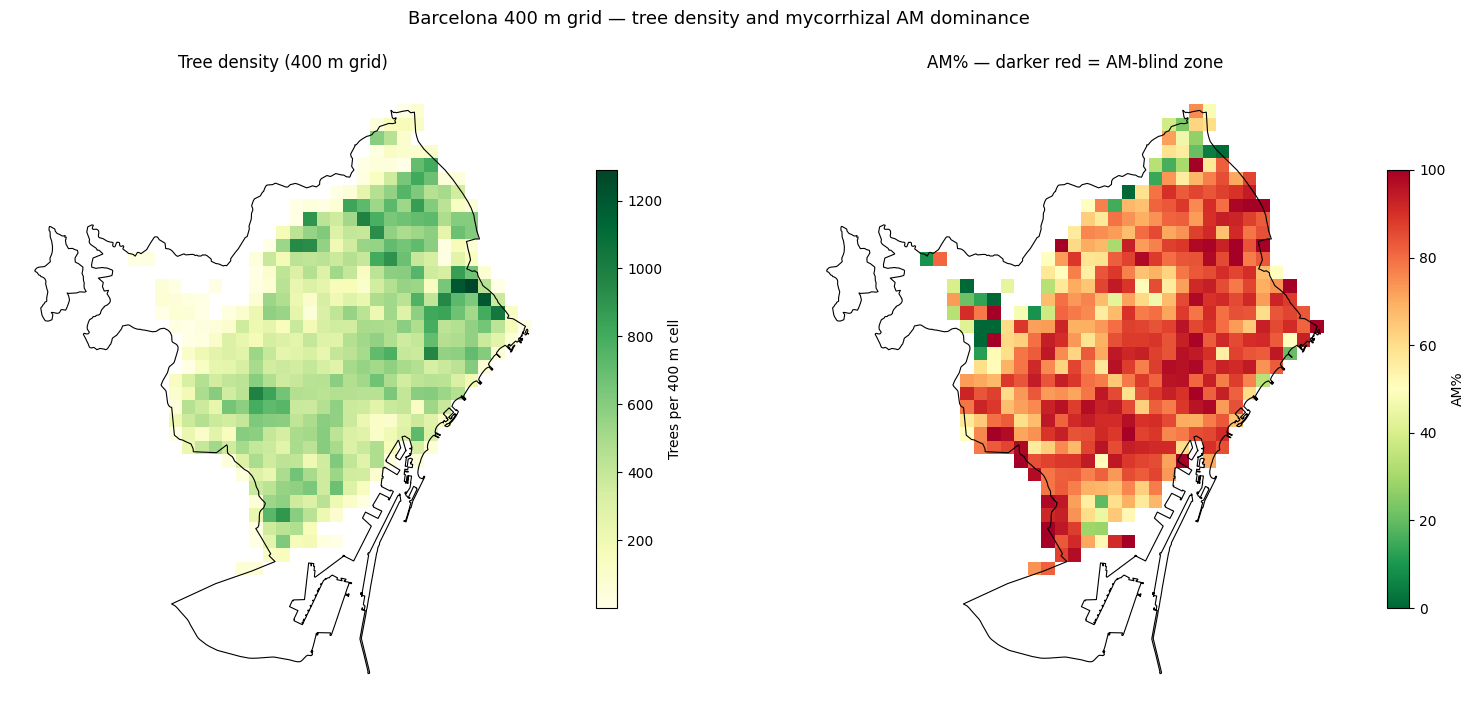

In [57]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left: tree count ─────────────────────────────────────────────────
    grid_out.plot(
        column="tree_count",
        ax=axes[0],
        legend=True,
        cmap="YlGn",
        legend_kwds={"label": "Trees per 400 m cell", "shrink": 0.7},
        edgecolor="none",
        linewidth=0,
    )
    boundary.to_crs(CRS_PROJ).boundary.plot(ax=axes[0], color="black", linewidth=0.8)
    axes[0].set_title("Tree density (400 m grid)", fontsize=12)
    axes[0].set_axis_off()

    # ── Right: AM% (AM-blindness intensity) ──────────────────────────────
    grid_out.plot(
        column="am_pct",
        ax=axes[1],
        legend=True,
        cmap="RdYlGn_r",   # red = high AM% (blind), green = more EM
        vmin=0, vmax=100,
        legend_kwds={"label": "AM%", "shrink": 0.7},
        edgecolor="none",
        linewidth=0,
    )
    boundary.to_crs(CRS_PROJ).boundary.plot(ax=axes[1], color="black", linewidth=0.8)
    axes[1].set_title("AM% — darker red = AM-blind zone", fontsize=12)
    axes[1].set_axis_off()

    plt.suptitle(
        "Barcelona 400 m grid — tree density and mycorrhizal AM dominance",
        fontsize=13, y=1.01
    )
    plt.tight_layout()

    fig_path = DATA_DIR.parent / "outputs" / "grid_trees_map.png"
    fig_path.parent.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Map saved: {fig_path}")
    plt.show()

except ImportError:
    print("matplotlib not available — skipping visualisation.")